In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/subset_train.csv")

print("Shape:", df.shape)
print("\nUnique images:", df['image_id'].nunique())
print("\nAll classes:")
print(df['class_name'].value_counts())

Shape: (22839, 8)

Unique images: 5000

All classes:
class_name
No finding            10473
Aortic enlargement     2511
Cardiomegaly           1932
Pleural thickening     1641
Pulmonary fibrosis     1594
Nodule/Mass             844
Pleural effusion        843
Lung Opacity            826
Other lesion            726
Infiltration            421
Calcification           348
ILD                     317
Consolidation           191
Atelectasis             107
Pneumothorax             65
Name: count, dtype: int64


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from sklearn.metrics import f1_score, roc_auc_score

os.chdir(r"C:\Lucky\CliniScan\B13-CliniScan")
print("✅ Imports done")
print("Torch version:", torch.__version__)

✅ Imports done
Torch version: 2.10.0+cpu


In [2]:
multi_label = pd.read_csv("data/raw/multilabel_matrix.csv")
train_df = pd.read_csv("data/raw/train_split.csv")
val_df = pd.read_csv("data/raw/val_split.csv")
test_df = pd.read_csv("data/raw/test_split.csv")

IMG_DIR = "data/processed"
IMG_SIZE = 224
NUM_CLASSES = 14
CLASS_NAMES = list(multi_label.columns[1:])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ Data loaded")
print("Device:", device)
print("Classes:", CLASS_NAMES)

✅ Data loaded
Device: cpu
Classes: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']


In [3]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.df.iloc[:, 1:].values.astype('float32')
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx])
        return image, label

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = ChestXrayDataset(test_df, IMG_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("✅ Dataset ready")

✅ Dataset ready


In [4]:
model = models.resnet50(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)
model.load_state_dict(torch.load("data/best_model.pth", map_location=device))
model.eval()

criterion = nn.BCEWithLogitsLoss()

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    preds_binary = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, preds_binary, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except:
        auc = 0.0
    return running_loss / len(loader), f1, auc

train_losses = [0.2084, 0.1834, 0.1680, 0.1647, 0.1608, 0.1524, 0.1496, 0.1493, 0.1419, 0.1405]
val_losses   = [0.2006, 0.1846, 0.1881, 0.2009, 0.1798, 0.1671, 0.1695, 0.1879, 0.1563, 0.1744]
val_f1s      = [0.0830, 0.1117, 0.0905, 0.0888, 0.1401, 0.1338, 0.1755, 0.1381, 0.2088, 0.2704]

print("✅ Model loaded and ready!")

✅ Model loaded and ready!


In [5]:
import os

processed_path = "data/processed"
all_images = os.listdir(processed_path)

print("Total PNG files:", len(all_images))
print("\nSample filenames:")
for img in all_images[:5]:
    print(img)

Total PNG files: 5000

Sample filenames:
0005e8e3701dfb1dd93d53e2ff537b6e.png
000ae00eb3942d27e0b97903dd563a6e.png
001d127bad87592efe45a5c7678f8b8d.png
0021df30f3fddef551eb3df4354b1d06.png
003cfe5ce5c0ec5163138eb3b740e328.png


In [6]:
# Image IDs from CSV
csv_ids = set(df['image_id'].unique())

# Image files from folder (remove .png extension)
folder_ids = set([f.replace('.png', '') for f in all_images if f.endswith('.png')])

# Check match
matched = csv_ids & folder_ids
print("CSV mein images:", len(csv_ids))
print("Folder mein images:", len(folder_ids))
print("Match hone wali images:", len(matched))
print("CSV mein hain but folder mein nahi:", len(csv_ids - folder_ids))

CSV mein images: 5000
Folder mein images: 5000
Match hone wali images: 1670
CSV mein hain but folder mein nahi: 3330


In [8]:
# train.csv load karo
df_train = pd.read_csv("data/raw/train.csv")

print("train.csv shape:", df_train.shape)
print("Unique images in train.csv:", df_train['image_id'].nunique())
print("\nColumns:", df_train.columns.tolist())

train.csv shape: (67914, 8)
Unique images in train.csv: 15000

Columns: ['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max']


In [9]:
# Apni 5000 folder images se match karo train.csv se
df_filtered = df_train[df_train['image_id'].isin(folder_ids)]

print("Matched images:", df_filtered['image_id'].nunique())
print("Shape:", df_filtered.shape)
print("\nClass distribution:")
print(df_filtered['class_name'].value_counts())

Matched images: 5000
Shape: (22507, 8)

Class distribution:
class_name
No finding            10647
Aortic enlargement     2315
Cardiomegaly           1733
Pleural thickening     1576
Pulmonary fibrosis     1528
Nodule/Mass             884
Pleural effusion        846
Lung Opacity            843
Other lesion            733
Infiltration            403
ILD                     364
Calcification           308
Consolidation           149
Atelectasis             105
Pneumothorax             73
Name: count, dtype: int64


In [10]:
# Yeh naya correct CSV save karo
df_filtered.to_csv("data/raw/my_5000_labels.csv", index=False)
print("✅ Saved: data/raw/my_5000_labels.csv")

✅ Saved: data/raw/my_5000_labels.csv


In [15]:
# No finding ko hatao
df_findings = df_filtered[df_filtered['class_name'] != 'No finding'].copy()

# Multi-label matrix banao
multi_label = pd.crosstab(
    df_findings['image_id'], 
    df_findings['class_name']
).clip(upper=1)

# folder_ids set se list banao — fix
all_image_ids_list = list(folder_ids)

# Sab 5000 images include karo (No finding wali bhi)
multi_label = multi_label.reindex(all_image_ids_list, fill_value=0)
multi_label.index.name = 'image_id'

print("Matrix shape:", multi_label.shape)
print("\nSample:")
print(multi_label.head())

Matrix shape: (5000, 14)

Sample:
class_name                        Aortic enlargement  Atelectasis  \
image_id                                                            
08c182c884fec1fad1b1e4a19d482acf                   0            0   
f0105dcab1f42815442e5a2b0247eb21                   1            0   
6ea15719175fe67480dc337f5e3ebd8a                   0            0   
c830bfa2f244f63cf2ded1ec5bd4dc40                   0            0   
6cf0ce690ad8348d8c44c689aed97836                   1            0   

class_name                        Calcification  Cardiomegaly  Consolidation  \
image_id                                                                       
08c182c884fec1fad1b1e4a19d482acf              0             0              0   
f0105dcab1f42815442e5a2b0247eb21              0             1              0   
6ea15719175fe67480dc337f5e3ebd8a              0             0              0   
c830bfa2f244f63cf2ded1ec5bd4dc40              0             0              0   
6c

In [16]:
# Kitni images mein kitni diseases hain
label_counts = multi_label.sum(axis=1)
print("Images with 0 findings (No finding):", (label_counts == 0).sum())
print("Images with 1 finding:", (label_counts == 1).sum())
print("Images with 2+ findings:", (label_counts >= 2).sum())

# Class wise total
print("\nPer class total positives:")
print(multi_label.sum().sort_values(ascending=False))

Images with 0 findings (No finding): 3549
Images with 1 finding: 133
Images with 2+ findings: 1318

Per class total positives:
class_name
Aortic enlargement    995
Cardiomegaly          728
Pleural thickening    651
Pulmonary fibrosis    529
Lung Opacity          453
Other lesion          375
Pleural effusion      343
Nodule/Mass           258
Infiltration          205
Calcification         147
ILD                   130
Consolidation         105
Atelectasis            69
Pneumothorax           32
dtype: int64


In [17]:
multi_label.reset_index(inplace=True)
multi_label.rename(columns={'index': 'image_id'}, inplace=True)
multi_label.to_csv("data/raw/multilabel_matrix.csv", index=False)
print("✅ Saved: data/raw/multilabel_matrix.csv")
print("Columns:", multi_label.columns.tolist())

✅ Saved: data/raw/multilabel_matrix.csv
Columns: ['image_id', 'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']


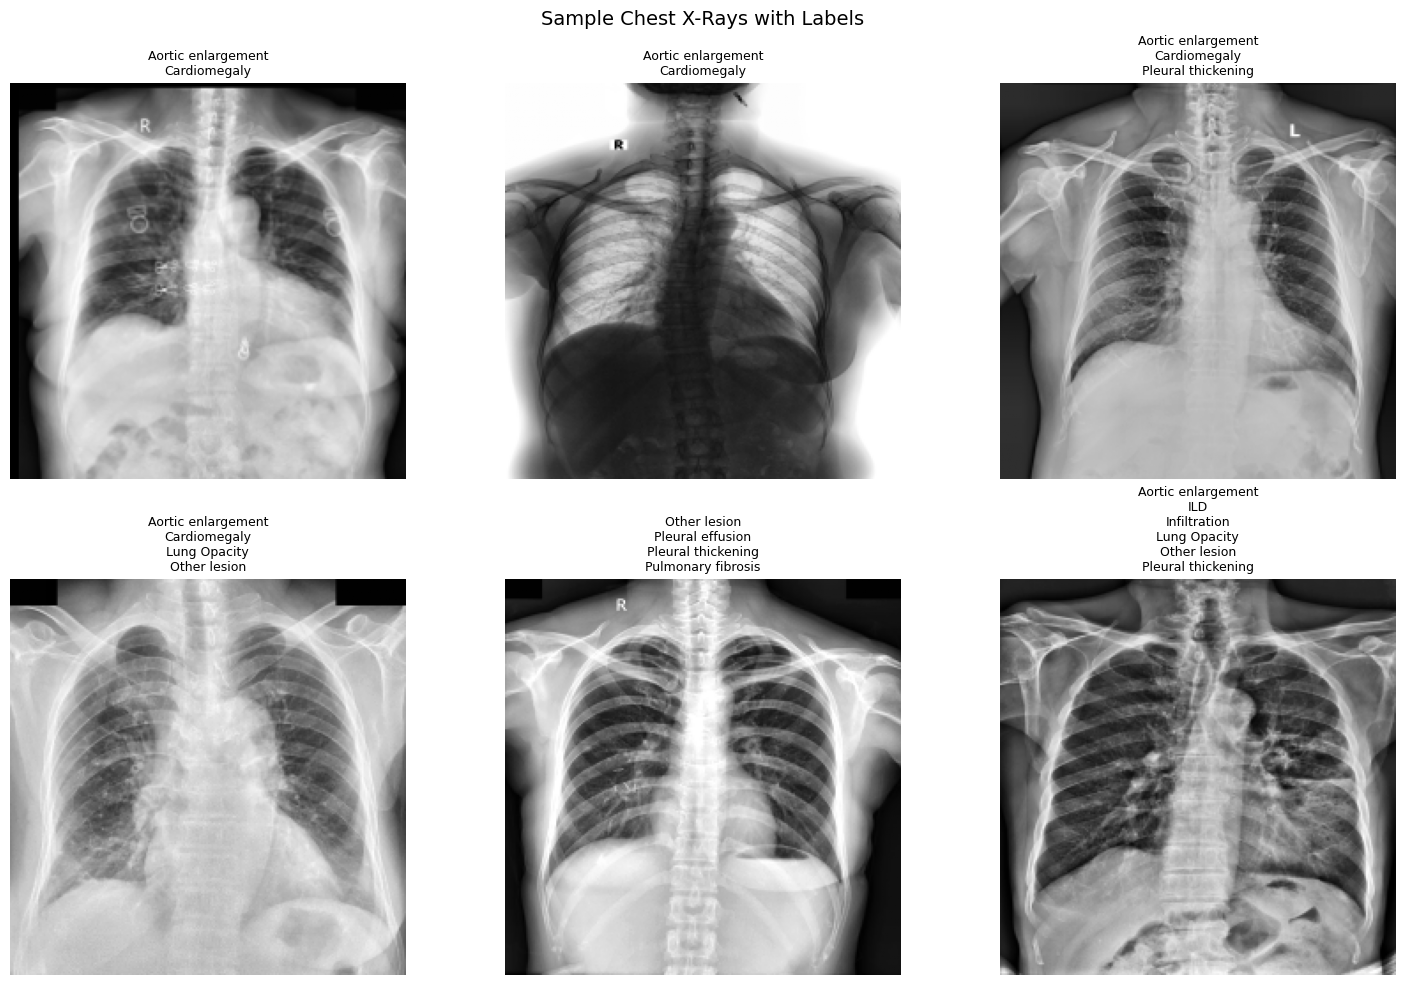

✅ Saved sample visualization


In [18]:
import cv2
import matplotlib.pyplot as plt

# Kuch finding wali images lo
sample_images = multi_label[multi_label.iloc[:, 1:].sum(axis=1) > 0].head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_images.iterrows()):
    img_path = f"data/processed/{row['image_id']}.png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Labels nikalo
    labels = [col for col in multi_label.columns[1:] if row[col] == 1]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title('\n'.join(labels), fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Chest X-Rays with Labels", fontsize=14)
plt.tight_layout()
plt.savefig("data/processed/sample_images.png")
plt.show()
print("✅ Saved sample visualization")

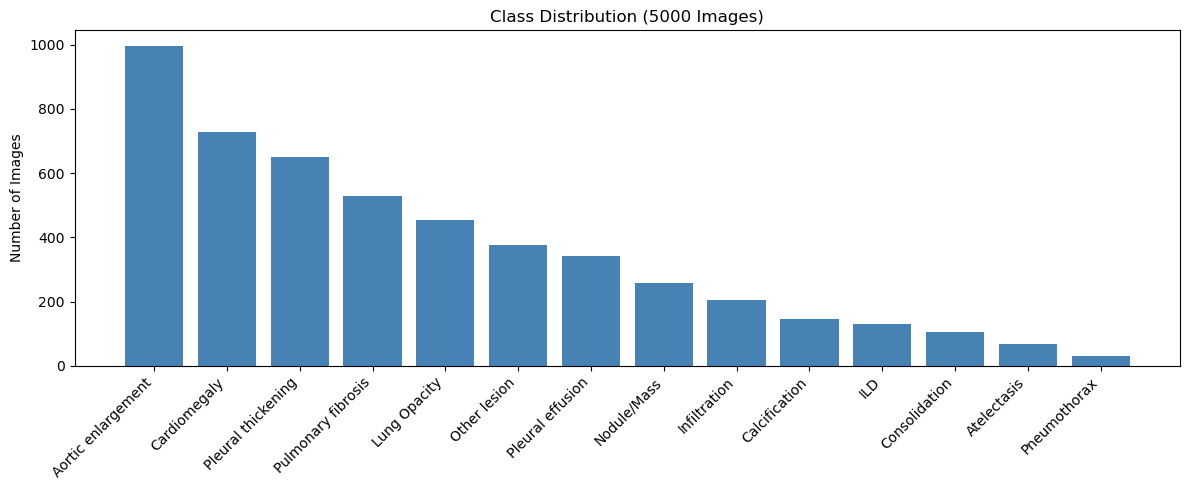

In [19]:
class_counts = multi_label.iloc[:, 1:].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_counts.index, class_counts.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (5000 Images)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("data/processed/class_distribution.png")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# Image IDs aur labels alag karo
image_ids = multi_label['image_id'].values
labels = multi_label.iloc[:, 1:].values

# Pehle 80% train, 20% temp
train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    image_ids, labels, 
    test_size=0.2, 
    random_state=42
)

# Phir temp ko 50/50 — 10% val, 10% test
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, 
    test_size=0.5, 
    random_state=42
)

print("Train images:", len(train_ids))
print("Val images:  ", len(val_ids))
print("Test images: ", len(test_ids))

Train images: 4000
Val images:   500
Test images:  500


In [22]:
# Train
train_df = pd.DataFrame(train_ids, columns=['image_id'])
train_df = pd.concat([train_df, pd.DataFrame(train_labels, columns=multi_label.columns[1:])], axis=1)
train_df.to_csv("data/raw/train_split.csv", index=False)

# Val
val_df = pd.DataFrame(val_ids, columns=['image_id'])
val_df = pd.concat([val_df, pd.DataFrame(val_labels, columns=multi_label.columns[1:])], axis=1)
val_df.to_csv("data/raw/val_split.csv", index=False)

# Test
test_df = pd.DataFrame(test_ids, columns=['image_id'])
test_df = pd.concat([test_df, pd.DataFrame(test_labels, columns=multi_label.columns[1:])], axis=1)
test_df.to_csv("data/raw/test_split.csv", index=False)

print("✅ Train split saved:", train_df.shape)
print("✅ Val split saved:  ", val_df.shape)
print("✅ Test split saved: ", test_df.shape)

✅ Train split saved: (4000, 15)
✅ Val split saved:   (500, 15)
✅ Test split saved:  (500, 15)


In [24]:
# Yeh naya correct CSV save karo
df_filtered.to_csv("data/raw/my_5000_labels.csv", index=False)
print("✅ Saved: data/raw/my_5000_labels.csv")

✅ Saved: data/raw/my_5000_labels.csv


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.df.iloc[:, 1:].values.astype('float32')
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['image_id']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        
        # Image load karo
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(self.labels[idx])
        return image, label

print("✅ Dataset class ready")

✅ Dataset class ready


In [27]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

print("✅ Transforms ready")

✅ Transforms ready


In [28]:
IMG_DIR = "data/processed"

train_dataset = ChestXrayDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = ChestXrayDataset(val_df,   IMG_DIR, transform=val_transform)
test_dataset  = ChestXrayDataset(test_df,  IMG_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

Train batches: 250
Val batches:   32
Test batches:  32


In [30]:
# Ek batch lo aur check karo
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample label:", labels[0])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16, 14])
Sample label: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [31]:
import torchvision.models as models
import torch.nn as nn

NUM_CLASSES = 14

# Pretrained ResNet50 load karo
model = models.resnet50(weights='DEFAULT')

# Final layer modify karo — 14 classes ke liye
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

print("✅ Model ready")
print("Final layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\sonil/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:52<00:00, 1.95MB/s]


✅ Model ready
Final layer: Linear(in_features=2048, out_features=14, bias=True)


In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = model.to(device)
print("✅ Model moved to", device)

Device: cpu
✅ Model moved to cpu


In [36]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    patience=2, 
    factor=0.5
)

print("✅ Criterion ready")
print("✅ Optimizer:", optimizer.__class__.__name__)
print("✅ Scheduler ready")

✅ Criterion ready
✅ Optimizer: Adam
✅ Scheduler ready


In [37]:
model.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)
    
    output = model(sample_images)
    print("Output shape:", output.shape)
    print("Sample output:", output[0])

Output shape: torch.Size([16, 14])
Sample output: tensor([ 0.0778,  0.1025, -0.2471,  0.3173, -0.0820, -0.2859, -0.0828, -0.2158,
        -0.1340,  0.0438,  0.1213,  0.0242,  0.0719,  0.0824])


In [38]:
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(loader)

In [39]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Sigmoid lagao predictions ke liye
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # F1 score
    preds_binary = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, preds_binary, average='macro', zero_division=0)
    
    # AUC
    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except:
        auc = 0.0
    
    return running_loss / len(loader), f1, auc

In [40]:
EPOCHS = 10
best_f1 = 0.0

train_losses = []
val_losses = []
val_f1s = []

print("Training start...\n")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_auc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val F1:     {val_f1:.4f}")
    print(f"  Val AUC:    {val_auc:.4f}")
    print("-" * 40)
    
    # Best model save karo
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "data/best_model.pth")
        print(f"  ✅ Best model saved! F1: {best_f1:.4f}")
    print()

print("Training Complete!")
print(f"Best Val F1: {best_f1:.4f}")

Training start...

Epoch [1/10]
  Train Loss: 0.2084
  Val Loss:   0.2006
  Val F1:     0.0830
  Val AUC:    0.7939
----------------------------------------
  ✅ Best model saved! F1: 0.0830

Epoch [2/10]
  Train Loss: 0.1834
  Val Loss:   0.1846
  Val F1:     0.1117
  Val AUC:    0.8096
----------------------------------------
  ✅ Best model saved! F1: 0.1117

Epoch [3/10]
  Train Loss: 0.1680
  Val Loss:   0.1881
  Val F1:     0.0905
  Val AUC:    0.8352
----------------------------------------

Epoch [4/10]
  Train Loss: 0.1647
  Val Loss:   0.2009
  Val F1:     0.0888
  Val AUC:    0.8524
----------------------------------------

Epoch [5/10]
  Train Loss: 0.1608
  Val Loss:   0.1798
  Val F1:     0.1401
  Val AUC:    0.8230
----------------------------------------
  ✅ Best model saved! F1: 0.1401

Epoch [6/10]
  Train Loss: 0.1524
  Val Loss:   0.1671
  Val F1:     0.1338
  Val AUC:    0.8635
----------------------------------------

Epoch [7/10]
  Train Loss: 0.1496
  Val Loss:   

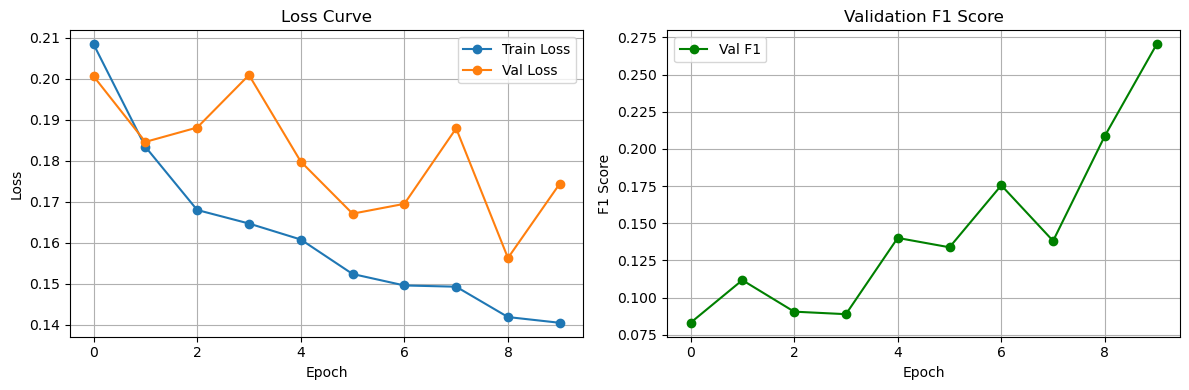

✅ Training curves saved


In [5]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# F1 plot
plt.subplot(1, 2, 2)
plt.plot(val_f1s, label='Val F1', marker='o', color='green')
plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("data/training_curves.png")
plt.show()
print("✅ Training curves saved")

In [6]:
# Best model load karo
model.load_state_dict(torch.load("data/best_model.pth"))

test_loss, test_f1, test_auc = validate(model, test_loader, criterion, device)

print("=" * 40)
print("FINAL TEST SET RESULTS")
print("=" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print(f"Test AUC:  {test_auc:.4f}")

FINAL TEST SET RESULTS
Test Loss: 0.1803
Test F1:   0.2967
Test AUC:  0.8844


In [7]:
CLASS_NAMES = list(multi_label.columns[1:])

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
preds_binary = (all_preds > 0.5).astype(int)

# Per class F1
per_class_f1 = f1_score(all_labels, preds_binary, average=None, zero_division=0)

print("Per Class F1 Scores:")
print("-" * 35)
for cls, score in zip(CLASS_NAMES, per_class_f1):
    print(f"{cls:<25}: {score:.4f}")

Per Class F1 Scores:
-----------------------------------
Aortic enlargement       : 0.8143
Atelectasis              : 0.0000
Calcification            : 0.0000
Cardiomegaly             : 0.8000
Consolidation            : 0.0000
ILD                      : 0.4000
Infiltration             : 0.0769
Lung Opacity             : 0.4602
Nodule/Mass              : 0.0000
Other lesion             : 0.1695
Pleural effusion         : 0.5000
Pleural thickening       : 0.5198
Pneumothorax             : 0.0000
Pulmonary fibrosis       : 0.4125
